# Model evolution: how the prediction stack earned its shape

This notebook is the executable companion to the dashboard's Research page.
It reconstructs the evolution of the FIFA Fantasy WC 2026 prediction models
from the evidence stored in the repository, using exactly the code paths the
dashboard uses (`fifa_fantasy.report`). Run it from the repository root with
the `[analysis]` extra installed:

```
pip install -e ".[dev,analysis]"
jupyter nbconvert --to notebook --execute --inplace notebooks/model_evolution.ipynb
```

Two kinds of numbers appear here and they must not be mixed. Held-out and
walk-forward tables never let a model see its test labels; they are the basis
for decisions. The realized backtest scores squads on rounds the WC-retrained
GBM later trained on, so its gbm and ensemble rows are upper bounds, useful
for narrative and unfair for comparison. The whitepaper
(`docs/whitepaper/`) is the full scholarly account.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import SVG, display

# Run from the repository root (the notebook lives in notebooks/).
if not Path("data/evaluation").exists() and Path("../data/evaluation").exists():
    import os
    os.chdir("..")
assert Path("data/evaluation").exists(), "run from the repository root"

from fifa_fantasy.report import data, figures, registry

figures.apply_style()
FIG_DIR = Path("results/figures")
EVAL = Path("data/evaluation")
TRAINING = Path("data/training")
PROCESSED = Path("data/processed")

pd.set_option("display.max_colwidth", 90)

## 1. The model registry

Every backend and generation this project has run, with its status and the
artifact that justifies it. This registry is the reconciliation the project
lacked while the story was spread across six modules, thirty whitepaper
sections and four evaluation files.

In [2]:
records = registry.MODEL_REGISTRY + registry.GENERATIONS
pd.DataFrame([
    {"key": r.key, "generation": r.generation, "status": r.status,
     "introduced": r.introduced, "routing_role": r.routing_role or "",
     "in_production_tick": r.in_production_tick}
    for r in records
]).set_index("key")

,generation,status,introduced,routing_role,in_production_tick
key,,,,,
heuristic,Heuristic v1,shipped,2026-06-07,Routed the DEF position by the ensemble,True
poisson,Poisson (GK formula v2),shipped,2026-06-07,Routed the GK position by the ensemble,True
gbm,GBM v3form,shipped,2026-07-08,Routed the MID and FWD positions by the ensemble,True
monte_carlo,Monte Carlo simulator,experimental,2026-06-28,,False
ensemble,Per-position ensemble,shipped,2026-07-08,The production default; the official squad comes from it,True
gbm_v1,GBM v1,superseded,2026-06-07,,False
gbm_v2,GBM v2,superseded,2026-06-07,,False
heuristic_v2,Heuristic v2,rejected,2026-06-28,,False


## 2. Realized performance across completed rounds

The cross-model backtest (`scripts/model_backtest.py`) rebuilds every
backend's squad for each completed round and scores it with realized fantasy
points, next to the user's actual squad and a 500-trial random baseline.

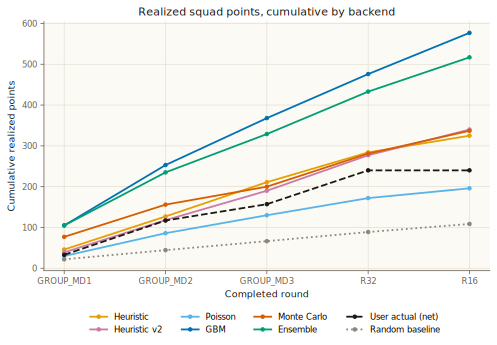

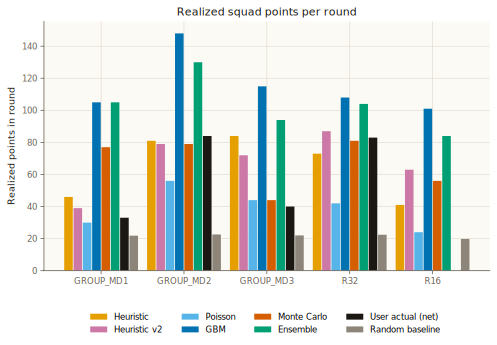

,heuristic,heuristic_v2,poisson,gbm,monte_carlo,ensemble,user_actual,random_baseline
GROUP_MD1,46.0,39.0,30.0,105.0,77.0,105.0,33.0,21.854
GROUP_MD2,81.0,79.0,56.0,148.0,79.0,130.0,84.0,22.566
GROUP_MD3,84.0,72.0,44.0,115.0,44.0,94.0,40.0,21.988
R32,73.0,87.0,42.0,108.0,81.0,104.0,83.0,22.400
R16,41.0,63.0,24.0,101.0,56.0,84.0,0.0,19.810


In [3]:
bt = data.load_backtest(EVAL)
display(SVG(str(figures.fig_backtest_cumulative(bt, FIG_DIR / "fig_backtest_cumulative.svg"))))
display(SVG(str(figures.fig_backtest_rounds(bt, FIG_DIR / "fig_backtest_rounds.svg"))))
pd.DataFrame(bt["series"], index=[r["stage"] for r in bt["rounds"]])

No backend wins every round, which is the empirical case for per-position
routing rather than a single champion. The gbm and ensemble columns carry the
in-sample caveat stated at the top.

## 3. Held-out validation and the ensemble routing

The canonical benchmark holds out EPL 2024-25 gameweeks 30 to 38. Poisson
wins goalkeepers, the heuristic wins defenders, the GBM wins midfielders and
forwards. The production ensemble applies exactly this table per position,
re-derived from the live validation report on every render.

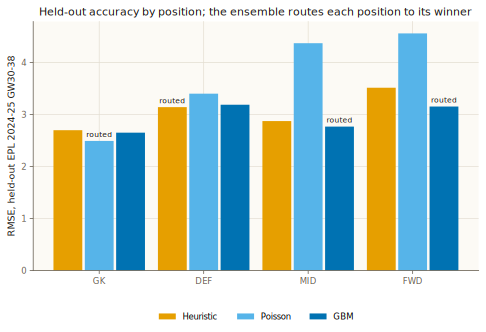

live routing: {'GK': 'poisson', 'DEF': 'heuristic', 'MID': 'gbm', 'FWD': 'gbm'}


,position,n,heuristic_rmse,poisson_rmse,gbm_rmse
0,GK,180,2.698005,2.490697,2.649654
1,DEF,910,3.141283,3.400080,3.187389
2,MID,1228,2.873832,4.371037,2.766783
3,FWD,368,3.514517,4.560273,3.153045


In [4]:
validation = data.load_validation_report(TRAINING)
routing = data.derive_routing(TRAINING)
display(SVG(str(figures.fig_holdout_rmse(validation, routing, FIG_DIR / "fig_holdout_rmse.svg"))))
print("live routing:", routing)
pd.DataFrame(validation)

## 4. Walk-forward validation on realized World Cup rounds

The EPL benchmark cannot answer whether a change survives the shift to
international football, so `scripts/wc_forward_validation.py` trains strictly
on data before each completed round and predicts that round, leak-free.
Config A is the old form-blind EPL-only model, B adds the trailing-form
feature, C (shipped) additionally retrains on completed WC rounds, and D adds
the minutes features that were rejected on this exact evidence.

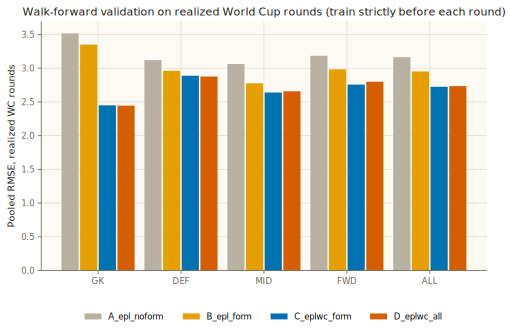

,GK,DEF,MID,FWD,ALL
A_epl_noform,3.517282,3.121603,3.062537,3.184542,3.164122
B_epl_form,3.350468,2.961910,2.775611,2.983810,2.952053
C_eplwc_form,2.449633,2.889154,2.639899,2.757175,2.724317
D_eplwc_all,2.444670,2.876979,2.658544,2.799775,2.734736


In [5]:
wf = data.load_walkforward(EVAL)
display(SVG(str(figures.fig_walkforward(wf, FIG_DIR / "fig_walkforward.svg"))))
pd.DataFrame(wf["pooled"]).T

## 5. Calibration of pre-match predictions

For every completed round, the last prediction made while the fixture was
still scheduled is compared with the points the player then scored. Labels
come only from realized data and predictions only from before kickoff; a
player whose team did not play a round is dropped, never zero-filled.
Coverage per backend reflects what actually ran on a given day.

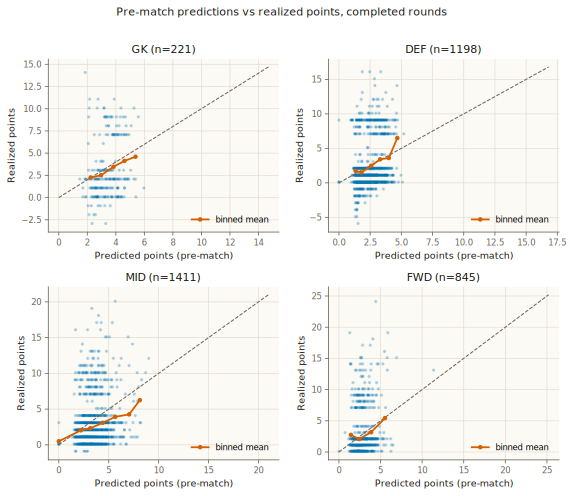

,model_backend,position,n,rmse,mae,spearman_rho
0,ensemble,DEF,10,2.550204,2.344177,0.728811
1,ensemble,FWD,6,1.238776,1.015436,0.338062
2,ensemble,GK,2,3.254083,3.163141,NaN
3,ensemble,MID,13,2.315200,1.547700,0.537573
4,gbm,DEF,1188,3.468722,2.693672,0.220066
5,gbm,FWD,839,3.459283,2.477272,0.183751
6,gbm,GK,219,3.324888,2.759374,0.238152
7,gbm,MID,1398,3.159906,2.415988,0.157490


In [6]:
calib = data.load_calibration(PROCESSED)
display(SVG(str(figures.fig_calibration(calib, FIG_DIR / "fig_calibration.svg"))))
pd.DataFrame(data.calibration_summary(calib))

## 6. The goalkeeper formula: theory against measurement

The save bonus began as a flat constant, was re-derived from first principles
at 1.13 per unit of opponent xG, and shipped at the empirically calibrated
0.50 after the sweep showed the derivation overestimates. The episode set the
project rule that derivations propose and measurements decide (whitepaper
section 09c).

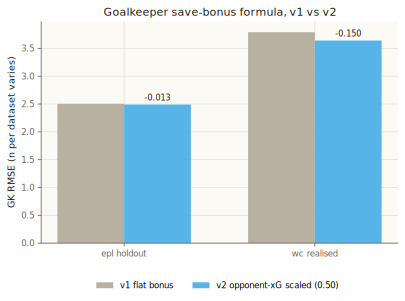

,dataset,position,n,rmse_v1,rmse_v2,mae_v1,mae_v2,delta_rmse
0,epl_holdout,GK,180,2.503426,2.490697,2.131694,2.032348,-0.012729
1,epl_holdout,DEF,910,3.400080,3.400080,2.880586,2.880586,0.000000
2,epl_holdout,MID,1228,4.371037,4.371037,4.011151,4.011151,0.000000
3,epl_holdout,FWD,368,4.560273,4.560273,4.191845,4.191845,0.000000
4,wc_realised,GK,168,3.789910,3.640201,2.769017,2.766291,-0.149709


In [7]:
gk = data.load_gk_sweep(EVAL)
display(SVG(str(figures.fig_gk_sweep(gk, FIG_DIR / "fig_gk_sweep.svg"))))
pd.DataFrame(gk)

## 7. Negative results

Rejected ideas are results. Each row was built, measured under the same gates
as everything that shipped, and turned down on the numbers.

In [8]:
pd.DataFrame([
    {"idea": nr.label, "tested": nr.tested, "measurement": nr.measured,
     "evidence": "; ".join(nr.evidence)}
    for nr in registry.NEGATIVE_RESULTS
]).set_index("idea")

,tested,measurement,evidence
idea,,,
Heuristic v2 component stack,2026-06-28,Cumulative realized points 190 vs 211 for unmodified v1,data/evaluation/backtest_summary.json
team_elo_diff as a GBM feature,2026-07-08,"EPL held-out RMSE: GK -0.018, MID -0.019, DEF +0.033, FWD +0.015",src/fifa_fantasy/model/gbm.py
"GK save bonus, theoretical 1.13 multiplier",2026-06-28,"Empirical sweep minimum at 0.50, not the derived 1.13",data/evaluation/gk_formula_ab_2026-06-29.json; scripts/gk_formula_ab.py
start_rate_lag and team_gc_form as GBM features,2026-07-08,Pooled walk-forward RMSE 3.281 to 3.307 when added,data/evaluation/wc_forward_validation.json; scripts/wc_forward_validation.py
Benter combiner with Polymarket prices,2026-06-28,delta RMSE positive for all backend-round pairs (combined worse),data/evaluation/with_vs_without_market.json; scripts/with_vs_without_market.py
GK defensive-form adjustment,2026-07-08,Walk-forward GK RMSE regressed when applied,scripts/wc_forward_validation.py


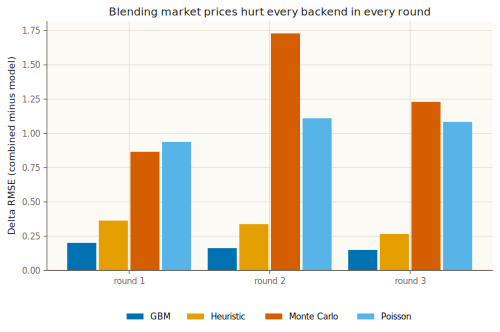

,count,mean,min,max
backend,,,,
gbm,3.0,0.171265,0.149934,0.201155
heuristic,3.0,0.322750,0.266140,0.363933
monte_carlo,3.0,1.275458,0.865924,1.730103
poisson,3.0,1.044248,0.937693,1.110559


In [9]:
market = data.load_market_negative(EVAL)
display(SVG(str(figures.fig_market_negative(market, FIG_DIR / "fig_market_negative.svg"))))
rows = pd.DataFrame(market["rows"])
rows.groupby("backend")["delta_rmse"].describe()[["count", "mean", "min", "max"]]

Every backend-round pair has a positive delta: blending Polymarket
tournament-winner prices into per-player, per-match predictions only added
noise. Market data stays on the dashboard's Intelligence page as context and
deliberately does not feed the models (whitepaper section 11d).

## 8. Closing notes

The through-line of the project is procedural rather than algorithmic. One
component at a time, each behind a held-out gate; when live rounds exist,
walk-forward beats intuition; theory proposes, measurement decides; and
rejected ideas get written down with their numbers so they stay rejected.

Pointers for the full account: whitepaper sections 07 (validation),
11f (model improvement retrospective), 11g (minutes, captaincy, variance),
11h (full system review), 09c (GK formula evolution), 05c (heuristic v2),
11d (market integration). The dashboard renders this same material live from
the repository artifacts.